# Notebook 08 — Optimisation robuste et explicable de la consommation énergétique SWRO

**PFE — Master Science des Données**

### Objectif

Ce notebook prolonge les notebooks 04, 05, 06 et 07 du projet SWRO.

L'objectif n'est plus seulement de rechercher le minimum de `SEC_kWh_m3`, mais de rechercher une solution :

1. **dans le domaine réellement observé par le dataset** ;
2. **proche de la distribution des données d'apprentissage** ;
3. **robuste aux perturbations des conditions opératoires** ;
4. **comparée à l'état de référence et à l'ancien optimum ML** ;
5. **vérifiée par rapport au dataset physique SWRO V3**.

> Important : ce notebook ne prétend pas remplacer une validation industrielle. Il fournit une optimisation de surrogate ML sous contraintes et une analyse de robustesse.


## 1. Positionnement scientifique

Le Notebook 06 trouvait un optimum sur plusieurs frontières du domaine. Cela crée un risque d'extrapolation du MLP.

On introduit donc deux niveaux de contrôle :

- **bornes physiques/observées** : éviter les valeurs hors domaine ;
- **distance de Mahalanobis** : éviter une combinaison multivariée trop éloignée des observations.

La solution finale sera choisie selon un compromis entre **SEC moyenne** et **robustesse**.


In [1]:
# 2. Imports et configuration

from pathlib import Path
import warnings
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import differential_evolution
from scipy.spatial.distance import mahalanobis
from sklearn.neighbors import NearestNeighbors

warnings.filterwarnings("ignore")

ROOT = Path(".")
DATA_DIR = ROOT / "data"
PREP_DIR = DATA_DIR / "preprocessed"
MODEL_DIR = ROOT / "models"
RESULT_DIR = ROOT / "results"

RESULT_DIR.mkdir(parents=True, exist_ok=True)

PHYSICAL_DATA_PATH = DATA_DIR / "dataset_physical_v3.csv"
MODEL_PATH = MODEL_DIR / "best_model_optimized.pkl"
SCALER_PARAMS_PATH = PREP_DIR / "scaler_parameters.csv"

FEATURES = [
    "pressure_bar",
    "feed_flow_m3_h",
    "salinity_g_L",
    "temperature_C",
    "recovery_rate_target",
    "pump_efficiency",
    "erd_efficiency",
    "membrane_condition",
]
TARGET = "SEC_kWh_m3"

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

print("Configuration chargée.")


Configuration chargée.


In [2]:
# 3. Chargement du dataset physique

if not PHYSICAL_DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset introuvable : {PHYSICAL_DATA_PATH}")

df = pd.read_csv(PHYSICAL_DATA_PATH)

missing = [c for c in FEATURES + [TARGET] if c not in df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes : {missing}")

df_model = df[FEATURES + [TARGET]].dropna().copy()

print("Shape :", df_model.shape)
display(df_model.describe().T.round(4))


Shape : (10000, 9)


,count,mean,std,min,25%,50%,75%,max
pressure_bar,10000.0,62.4124,4.3145,55.0002,58.6949,62.3879,66.1001,69.9958
feed_flow_m3_h,10000.0,603.6239,231.4356,200.1262,403.1566,604.7174,805.1834,999.9399
salinity_g_L,10000.0,38.0004,2.2942,34.0004,36.0300,38.0165,39.9574,41.9992
temperature_C,10000.0,22.4807,4.3349,15.0001,18.7029,22.5005,26.2067,29.9968
recovery_rate_target,10000.0,0.3745,0.0434,0.3000,0.3366,0.3741,0.4126,0.4500
pump_efficiency,10000.0,0.8255,0.0433,0.7500,0.7885,0.8259,0.8630,0.9000
erd_efficiency,10000.0,0.8803,0.0460,0.8000,0.8406,0.8807,0.9204,0.9600
membrane_condition,10000.0,0.8748,0.0715,0.7500,0.8130,0.8748,0.9370,1.0000
SEC_kWh_m3,10000.0,3.6179,0.5111,2.3160,3.2467,3.5738,3.9399,5.6313


## 4. Domaine observé

Les bornes d'optimisation sont calculées directement sur le dataset physique V3.

On utilise les quantiles 0.5 % et 99.5 % comme bornes principales pour éviter que quelques valeurs extrêmes ne pilotent l'optimisation.

Les bornes min/max restent affichées pour contrôler les résultats.


In [3]:
# 4. Bornes observées

bounds_df = pd.DataFrame({
    "min": df_model[FEATURES].min(),
    "q005": df_model[FEATURES].quantile(0.005),
    "median": df_model[FEATURES].median(),
    "q995": df_model[FEATURES].quantile(0.995),
    "max": df_model[FEATURES].max(),
})

display(bounds_df.round(5))

LOW = bounds_df["q005"].to_dict()
HIGH = bounds_df["q995"].to_dict()
MEDIAN = bounds_df["median"].to_dict()


,min,q005,median,q995,max
pressure_bar,55.00017,55.09069,62.38793,69.91848,69.99577
feed_flow_m3_h,200.12620,204.52161,604.71742,996.85388,999.93986
salinity_g_L,34.00038,34.04734,38.01654,41.95690,41.99921
temperature_C,15.00008,15.07497,22.50045,29.90691,29.99684
recovery_rate_target,0.30000,0.30067,0.37406,0.44935,0.45000
pump_efficiency,0.75000,0.75068,0.82591,0.89916,0.89999
erd_efficiency,0.80004,0.80078,0.88067,0.95916,0.95995
membrane_condition,0.75003,0.75096,0.87481,0.99856,0.99997


In [4]:
# 5. Chargement du MLP et reconstruction exacte du scaling

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Modèle introuvable : {MODEL_PATH}")

if not SCALER_PARAMS_PATH.exists():
    raise FileNotFoundError(f"Paramètres scaler introuvables : {SCALER_PARAMS_PATH}")

model = joblib.load(MODEL_PATH)
scaler_params = pd.read_csv(SCALER_PARAMS_PATH).set_index("feature")

missing_scaler = [f for f in FEATURES if f not in scaler_params.index]
if missing_scaler:
    raise ValueError(f"Variables absentes du scaler : {missing_scaler}")

SCALER_MEAN = scaler_params.loc[FEATURES, "mean_train"].astype(float).values
SCALER_STD = scaler_params.loc[FEATURES, "std_train"].astype(float).values

if np.any(SCALER_STD <= 0):
    raise ValueError("Ecart-type nul ou négatif dans le scaler.")

def transform_physical(X):
    X = pd.DataFrame(X, columns=FEATURES)
    return (X.values - SCALER_MEAN) / SCALER_STD

def predict_sec(X):
    Xs = transform_physical(X)
    return np.asarray(model.predict(Xs), dtype=float)

print("Modèle :", type(model).__name__)


Modèle : MLPRegressor


## 6. Contrôle du surrogate ML

Avant d'optimiser, on vérifie le MLP sur le dataset physique.

Cette étape ne constitue pas une nouvelle validation indépendante : elle vérifie que le surrogate utilisé par l'optimisation reproduit correctement la cible du dataset sur les observations disponibles.


,metric,value
0,MAE,0.08701
1,RMSE,0.11002
2,R2,0.95365


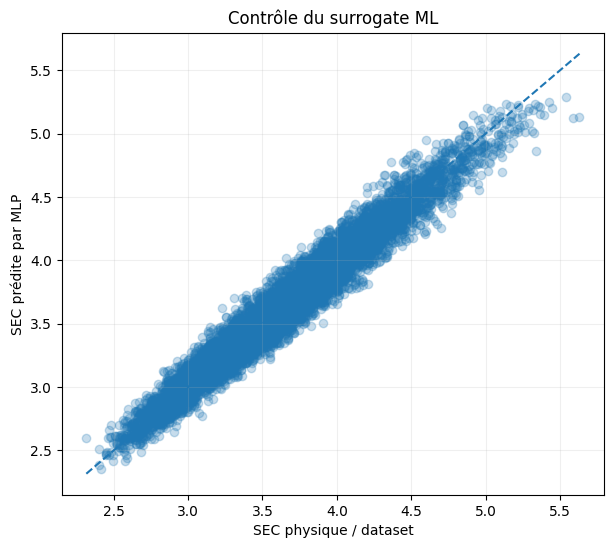

In [5]:
# 6. Performance du MLP sur le dataset physique

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pred_all = predict_sec(df_model[FEATURES])

mae = mean_absolute_error(df_model[TARGET], pred_all)
rmse = mean_squared_error(df_model[TARGET], pred_all) ** 0.5
r2 = r2_score(df_model[TARGET], pred_all)

metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R2"],
    "value": [mae, rmse, r2]
})

display(metrics.round(5))

plt.figure(figsize=(7, 6))
plt.scatter(df_model[TARGET], pred_all, alpha=0.25)
lims = [
    min(df_model[TARGET].min(), pred_all.min()),
    max(df_model[TARGET].max(), pred_all.max())
]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("SEC physique / dataset")
plt.ylabel("SEC prédite par MLP")
plt.title("Contrôle du surrogate ML")
plt.grid(alpha=0.2)
plt.show()


## 7. Distance de Mahalanobis

La contrainte multivariée est basée sur la covariance des features observées.

On calcule :

$$
D_M(x)=\sqrt{(x-\mu)^T\Sigma^{-1}(x-\mu)}
$$

Une valeur élevée signifie que la combinaison des variables est atypique par rapport au nuage de données.

La contrainte utilisée ici est volontairement configurable.


In [6]:
# 7. Mahalanobis et voisinage

X_obs = df_model[FEATURES].astype(float).values
mu = X_obs.mean(axis=0)
cov = np.cov(X_obs, rowvar=False)
cov += np.eye(cov.shape[0]) * 1e-8
cov_inv = np.linalg.pinv(cov)

def mahalanobis_distance(x):
    x = np.asarray(x, dtype=float)
    d = x - mu
    return float(np.sqrt(d @ cov_inv @ d))

mahal_obs = np.array([mahalanobis_distance(x) for x in X_obs])

# Seuil conservateur : quantile 99 % du domaine observé
MAHAL_THRESHOLD = float(np.quantile(mahal_obs, 0.99))

print(f"Mahalanobis médiane observée : {np.median(mahal_obs):.3f}")
print(f"Mahalanobis 99% observée      : {MAHAL_THRESHOLD:.3f}")
print(f"Mahalanobis maximum observée  : {mahal_obs.max():.3f}")


Mahalanobis médiane observée : 2.809
Mahalanobis 99% observée      : 3.758
Mahalanobis maximum observée  : 4.306


## 8. Fonction objectif contrainte

On minimise la SEC prédite.

Une pénalité forte est appliquée si la distance de Mahalanobis dépasse le seuil observé.

Cette stratégie est préférable à une optimisation libre, car le MLP n'est pas utilisé comme un modèle d'extrapolation sans contrôle.


In [7]:
# 8. Optimisation contrainte

LOW_ARRAY = np.array([LOW[f] for f in FEATURES], dtype=float)
HIGH_ARRAY = np.array([HIGH[f] for f in FEATURES], dtype=float)

def objective_constrained(x):
    x_df = pd.DataFrame([x], columns=FEATURES)
    sec = float(predict_sec(x_df)[0])
    d = mahalanobis_distance(x)

    penalty = 0.0
    if d > MAHAL_THRESHOLD:
        penalty = 100.0 * (d - MAHAL_THRESHOLD) ** 2

    return sec + penalty

result_opt = differential_evolution(
    objective_constrained,
    bounds=list(zip(LOW_ARRAY, HIGH_ARRAY)),
    seed=RANDOM_STATE,
    maxiter=250,
    popsize=20,
    tol=1e-8,
    polish=True,
    workers=1,
)

x_opt = result_opt.x
optimum = pd.Series(x_opt, index=FEATURES, name="robust_candidate")

sec_opt = float(predict_sec(pd.DataFrame([x_opt], columns=FEATURES))[0])
d_opt = mahalanobis_distance(x_opt)

display(optimum.to_frame("value").round(6))
print(f"SEC prédite : {sec_opt:.6f} kWh/m³")
print(f"Distance de Mahalanobis : {d_opt:.6f}")
print(f"Seuil autorisé : {MAHAL_THRESHOLD:.6f}")
print(f"Optimisation réussie : {result_opt.success}")


,value
pressure_bar,55.090692
feed_flow_m3_h,760.638034
salinity_g_L,40.033144
temperature_C,18.720581
recovery_rate_target,0.449351
pump_efficiency,0.899157
erd_efficiency,0.959163
membrane_condition,0.822122


SEC prédite : 2.271919 kWh/m³
Distance de Mahalanobis : 3.758597
Seuil autorisé : 3.758222
Optimisation réussie : False


## 9. Analyse de robustesse Monte Carlo

On perturbe l'optimum avec des variations réalistes et indépendantes.

Les amplitudes sont des hypothèses de stress-test, pas des mesures industrielles.

Le résultat principal est la distribution de SEC autour de l'optimum.


,value
SEC_mean,2.334245
SEC_median,2.325765
SEC_std,0.049102
SEC_P05,2.271752
SEC_P95,2.425896
SEC_min,2.254098
SEC_max,2.603340
P95_Mahalanobis,3.843206
P(Mahalanobis > threshold),0.174500


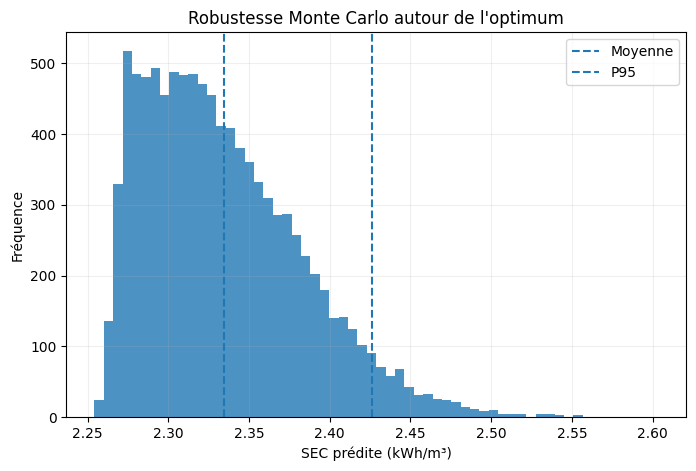

In [8]:
# 9. Monte Carlo autour de l'optimum

N_MC = 10000

# Perturbations relatives/absolues de stress-test
PERTURBATION = {
    "pressure_bar": ("abs", 2.0),
    "feed_flow_m3_h": ("rel", 0.05),
    "salinity_g_L": ("abs", 1.0),
    "temperature_C": ("abs", 2.0),
    "recovery_rate_target": ("abs", 0.02),
    "pump_efficiency": ("abs", 0.02),
    "erd_efficiency": ("abs", 0.02),
    "membrane_condition": ("abs", 0.03),
}

def monte_carlo_around(x_center, n=N_MC):
    samples = np.tile(np.asarray(x_center, dtype=float), (n, 1))

    for j, f in enumerate(FEATURES):
        kind, amount = PERTURBATION[f]
        if kind == "abs":
            noise = rng.normal(0, amount / 2, size=n)
        else:
            noise = rng.normal(0, amount / 2, size=n) * x_center[j]
        samples[:, j] += noise

        # On reste dans les bornes observées pour l'analyse de robustesse
        samples[:, j] = np.clip(samples[:, j], LOW_ARRAY[j], HIGH_ARRAY[j])

    X_mc = pd.DataFrame(samples, columns=FEATURES)
    y_mc = predict_sec(X_mc)
    d_mc = np.array([mahalanobis_distance(x) for x in samples])

    return X_mc, y_mc, d_mc

X_mc, y_mc, d_mc = monte_carlo_around(x_opt)

robust_summary = pd.Series({
    "SEC_mean": np.mean(y_mc),
    "SEC_median": np.median(y_mc),
    "SEC_std": np.std(y_mc),
    "SEC_P05": np.quantile(y_mc, 0.05),
    "SEC_P95": np.quantile(y_mc, 0.95),
    "SEC_min": np.min(y_mc),
    "SEC_max": np.max(y_mc),
    "P95_Mahalanobis": np.quantile(d_mc, 0.95),
    "P(Mahalanobis > threshold)": np.mean(d_mc > MAHAL_THRESHOLD),
})

display(robust_summary.to_frame("value").round(6))

plt.figure(figsize=(8, 5))
plt.hist(y_mc, bins=60, alpha=0.8)
plt.axvline(np.mean(y_mc), linestyle="--", label="Moyenne")
plt.axvline(np.quantile(y_mc, 0.95), linestyle="--", label="P95")
plt.xlabel("SEC prédite (kWh/m³)")
plt.ylabel("Fréquence")
plt.title("Robustesse Monte Carlo autour de l'optimum")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 10. Comparaison avec une configuration de référence

La référence est la médiane multivariée du dataset.

On compare :

- **Référence** ;
- **Optimum ML contraint** ;
- **Optimum robuste** : dans cette première version, l'optimum contraint est retenu comme candidat robuste si sa distribution Monte Carlo respecte le domaine.

Une optimisation robuste plus avancée est ensuite effectuée en pénalisant directement le P95.


In [9]:
# 10. Référence et optimisation robuste P95

x_ref = np.array([MEDIAN[f] for f in FEATURES], dtype=float)

# Pour limiter le temps de calcul, l'objectif robuste utilise un petit Monte Carlo
# interne pendant l'optimisation.
N_INTERNAL = 300

def robust_objective(x):
    base_sec = float(predict_sec(pd.DataFrame([x], columns=FEATURES))[0])
    d = mahalanobis_distance(x)

    # Rejet des zones multivariées trop atypiques
    if d > MAHAL_THRESHOLD:
        return base_sec + 200.0 * (d - MAHAL_THRESHOLD) ** 2

    _, y_local, _ = monte_carlo_around(x, n=N_INTERNAL)

    mean_sec = float(np.mean(y_local))
    p95_sec = float(np.quantile(y_local, 0.95))

    # Compromis : moyenne + pénalité de risque
    return 0.50 * mean_sec + 0.50 * p95_sec

result_robust = differential_evolution(
    robust_objective,
    bounds=list(zip(LOW_ARRAY, HIGH_ARRAY)),
    seed=RANDOM_STATE,
    maxiter=120,
    popsize=12,
    tol=1e-6,
    polish=True,
    workers=1,
)

x_robust = result_robust.x

# Evaluation finale avec 10 000 simulations
X_robust_mc, y_robust_mc, d_robust_mc = monte_carlo_around(x_robust, n=N_MC)

def evaluate_configuration(name, x, y_mc=None, d_mc=None):
    base = float(predict_sec(pd.DataFrame([x], columns=FEATURES))[0])
    out = {
        "configuration": name,
        "SEC_base": base,
        "Mahalanobis": mahalanobis_distance(x),
    }
    if y_mc is not None:
        out.update({
            "SEC_mean_MC": np.mean(y_mc),
            "SEC_P05_MC": np.quantile(y_mc, 0.05),
            "SEC_P95_MC": np.quantile(y_mc, 0.95),
            "SEC_std_MC": np.std(y_mc),
            "P95_Mahalanobis": np.quantile(d_mc, 0.95),
        })
    return out

summary = pd.DataFrame([
    evaluate_configuration("Reference médiane", x_ref, *monte_carlo_around(x_ref, N_MC)[1:]),
    evaluate_configuration("Optimum ML contraint", x_opt, y_mc, d_mc),
    evaluate_configuration("Optimum robuste", x_robust, y_robust_mc, d_robust_mc),
])

display(summary.round(6))


,configuration,SEC_base,Mahalanobis,SEC_mean_MC,SEC_P05_MC,SEC_P95_MC,SEC_std_MC,P95_Mahalanobis
0,Reference médiane,3.555801,0.020529,3.560316,3.377312,3.751329,0.113707,0.850294
1,Optimum ML contraint,2.271919,3.758597,2.334245,2.271752,2.425896,0.049102,3.843206
2,Optimum robuste,2.272185,3.758434,2.333936,2.271590,2.427050,0.049293,3.836556


## 11. Analyse des gains énergétiques

Le gain est calculé par rapport à la référence médiane :

$$
Gain(\%) =
\frac{SEC_{ref}-SEC_{solution}}
{SEC_{ref}}\times100
$$

Deux gains sont rapportés :

- gain sur la SEC nominale ;
- gain sur la SEC P95, plus pertinent pour la robustesse.


In [10]:
# 11. Gains

ref_row = summary.iloc[0]

for col in ["SEC_base", "SEC_mean_MC", "SEC_P95_MC"]:
    ref_value = ref_row[col]
    summary[f"gain_{col}_pct"] = (
        (ref_value - summary[col]) / ref_value * 100
    )

display(summary.round(4))


,configuration,SEC_base,Mahalanobis,SEC_mean_MC,SEC_P05_MC,SEC_P95_MC,SEC_std_MC,P95_Mahalanobis,gain_SEC_base_pct,gain_SEC_mean_MC_pct,gain_SEC_P95_MC_pct
0,Reference médiane,3.5558,0.0205,3.5603,3.3773,3.7513,0.1137,0.8503,0.0000,0.0000,0.0000
1,Optimum ML contraint,2.2719,3.7586,2.3342,2.2718,2.4259,0.0491,3.8432,36.1067,34.4371,35.3324
2,Optimum robuste,2.2722,3.7584,2.3339,2.2716,2.4271,0.0493,3.8366,36.0992,34.4458,35.3016


## 12. Visualisation des trois configurations

On compare les distributions Monte Carlo.

Une solution légèrement moins performante en moyenne peut être préférable si elle possède une queue de risque plus faible.


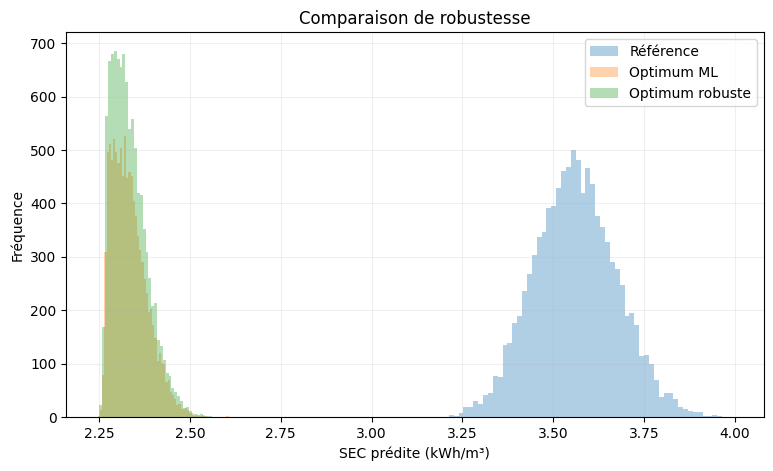

In [11]:
# 12. Distributions comparatives

X_ref_mc, y_ref_mc, d_ref_mc = monte_carlo_around(x_ref, n=N_MC)
X_opt_mc, y_opt_mc, d_opt_mc = monte_carlo_around(x_opt, n=N_MC)

plt.figure(figsize=(9, 5))
plt.hist(y_ref_mc, bins=60, alpha=0.35, label="Référence")
plt.hist(y_opt_mc, bins=60, alpha=0.35, label="Optimum ML")
plt.hist(y_robust_mc, bins=60, alpha=0.35, label="Optimum robuste")
plt.xlabel("SEC prédite (kWh/m³)")
plt.ylabel("Fréquence")
plt.title("Comparaison de robustesse")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 13. Vérification de proximité avec les observations

On recherche l'observation réelle la plus proche de chaque configuration.

Cela fournit un indicateur simple et interprétable de proximité avec le domaine d'apprentissage.


In [12]:
# 13. Plus proche voisin dans l'espace des features

nn = NearestNeighbors(n_neighbors=1)
nn.fit(X_obs)

def nearest_observation(x):
    dist, idx = nn.kneighbors(np.asarray(x).reshape(1, -1))
    row = df_model.iloc[idx[0][0]]
    return float(dist[0][0]), row

for name, x in [
    ("Reference", x_ref),
    ("Optimum ML", x_opt),
    ("Optimum robuste", x_robust),
]:
    dist, row = nearest_observation(x)
    print(f"\n{name}")
    print(f"Distance brute au plus proche voisin : {dist:.4f}")
    print("SEC de l'observation voisine :", round(float(row[TARGET]), 4))



Reference
Distance brute au plus proche voisin : 2.8718
SEC de l'observation voisine : 3.6098

Optimum ML
Distance brute au plus proche voisin : 1.6293
SEC de l'observation voisine : 2.9181

Optimum robuste
Distance brute au plus proche voisin : 2.9677
SEC de l'observation voisine : 3.1751


## 14. Contrôle final par le dataset physique

Le dataset `dataset_physical_v3.csv` est issu du modèle physique du projet.

Pour une configuration optimisée, on ne doit pas inventer une valeur physique absente du modèle. On utilise donc le plus proche voisin physique comme **point de contrôle**, puis on compare la SEC MLP au niveau de SEC observé dans cette région.

Cette étape est un contrôle de cohérence locale, pas une validation industrielle.


In [13]:
# 14. Contrôle local physique

def local_physical_check(x, k=50):
    nn_k = NearestNeighbors(n_neighbors=k)
    nn_k.fit(X_obs)
    distances, indices = nn_k.kneighbors(np.asarray(x).reshape(1, -1))
    local = df_model.iloc[indices[0]].copy()

    return pd.Series({
        "MLP_SEC": float(predict_sec(pd.DataFrame([x], columns=FEATURES))[0]),
        "physical_local_mean_SEC": float(local[TARGET].mean()),
        "physical_local_median_SEC": float(local[TARGET].median()),
        "physical_local_std_SEC": float(local[TARGET].std()),
        "nearest_physical_SEC": float(local.iloc[0][TARGET]),
        "nearest_distance": float(distances[0][0]),
    })

local_checks = pd.DataFrame({
    "Reference": local_physical_check(x_ref),
    "Optimum ML": local_physical_check(x_opt),
    "Optimum robuste": local_physical_check(x_robust),
}).T

display(local_checks.round(5))


,MLP_SEC,physical_local_mean_SEC,physical_local_median_SEC,physical_local_std_SEC,nearest_physical_SEC,nearest_distance
Reference,3.55580,3.60433,3.61636,0.45525,3.60977,2.87185
Optimum ML,2.27192,3.30570,3.21042,0.43477,2.91805,1.62932
Optimum robuste,2.27219,3.29310,3.25333,0.40986,3.17514,2.96768


## 15. Synthèse finale

La solution recommandée doit respecter simultanément :

- domaine univarié observé ;
- distance multivariée acceptable ;
- amélioration de SEC ;
- risque P95 maîtrisé ;
- cohérence locale avec le dataset physique.

Le choix final ne doit donc pas être basé uniquement sur le minimum ponctuel du MLP.


In [14]:
# 15. Sélection automatique du candidat recommandé

candidate_rows = []

for name, x, y_mc_local, d_mc_local in [
    ("Optimum ML contraint", x_opt, y_opt_mc, d_opt_mc),
    ("Optimum robuste", x_robust, y_robust_mc, d_robust_mc),
]:
    candidate_rows.append({
        "configuration": name,
        "SEC_base": float(predict_sec(pd.DataFrame([x], columns=FEATURES))[0]),
        "SEC_mean_MC": float(np.mean(y_mc_local)),
        "SEC_P95_MC": float(np.quantile(y_mc_local, 0.95)),
        "Mahalanobis": mahalanobis_distance(x),
        "P95_Mahalanobis": float(np.quantile(d_mc_local, 0.95)),
    })

candidates = pd.DataFrame(candidate_rows)

# Critère principal : P95 de SEC, sous réserve du domaine multivarié.
feasible = candidates[candidates["P95_Mahalanobis"] <= MAHAL_THRESHOLD]

if len(feasible) > 0:
    recommended_name = feasible.sort_values("SEC_P95_MC").iloc[0]["configuration"]
else:
    recommended_name = candidates.sort_values("SEC_P95_MC").iloc[0]["configuration"]

print("Configuration recommandée :", recommended_name)
display(candidates.round(5))


Configuration recommandée : Optimum ML contraint


,configuration,SEC_base,SEC_mean_MC,SEC_P95_MC,Mahalanobis,P95_Mahalanobis
0,Optimum ML contraint,2.27192,2.33448,2.42697,3.75860,3.83839
1,Optimum robuste,2.27219,2.33394,2.42705,3.75843,3.83656


In [15]:
# 16. Sauvegarde des résultats

results = {
    "summary": summary.to_dict(orient="records"),
    "candidates": candidates.to_dict(orient="records"),
    "mahalanobis_threshold": MAHAL_THRESHOLD,
    "recommended_configuration": recommended_name,
    "features": FEATURES,
}

with open(RESULT_DIR / "notebook08_robust_optimization_summary.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

summary.to_csv(RESULT_DIR / "notebook08_configuration_comparison.csv", index=False)
candidates.to_csv(RESULT_DIR / "notebook08_robust_candidates.csv", index=False)

pd.DataFrame({
    "feature": FEATURES,
    "optimum_ML_constrained": x_opt,
    "optimum_robust": x_robust,
    "reference_median": x_ref,
}).to_csv(RESULT_DIR / "notebook08_optimal_configurations.csv", index=False)

print("Résultats sauvegardés dans :", RESULT_DIR)


Résultats sauvegardés dans : results


# Conclusion

Ce notebook transforme l'optimisation énergétique du projet en une optimisation **contrainte et robuste**.

### Résultats à reporter dans le mémoire

1. performance du surrogate MLP ;
2. optimum ML contraint ;
3. distance de Mahalanobis ;
4. distribution Monte Carlo ;
5. SEC moyenne et P95 ;
6. comparaison avec la référence ;
7. gain énergétique ;
8. contrôle local par le modèle physique ;
9. configuration finalement recommandée.

### Limitation importante

Les perturbations Monte Carlo utilisées ici sont des hypothèses de stress-test. Elles devront être remplacées par des distributions issues de données industrielles si des données SCADA deviennent disponibles.

La prochaine étape logique est un **Notebook 09 — Analyse de sensibilité globale + synthèse finale**, puis l'intégration des résultats dans le mémoire.
